# Unsupervised Learning: Discovering Fitness Patterns in the Real World
Real-world data is rarely clean. It's often messy, overlapping, and filled with outliers (like forgetting to turn off a fitness tracker!).

In this updated module, we have a much messier dataset of mystery workouts. We'll use interactive tools to explore the data first, and then use a slider to see how **K-Means Clustering** adapts in real-time as we change the number of clusters (k).

In [18]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go

# 1. Generate messier, real-world fitness data
np.random.seed(42)

# Activity A: Low HR, medium duration (wider variance)
dur_A = np.random.normal(45, 15, 60)
hr_A = np.random.normal(95, 12, 60)

# Activity B: High HR, short duration
dur_B = np.random.normal(25, 8, 55)
hr_B = np.random.normal(160, 15, 55)

# Activity C: Medium HR, long duration
dur_C = np.random.normal(80, 20, 65)
hr_C = np.random.normal(145, 12, 65)

# Outliers: (e.g., glitches, ultra-endurance events, tracker left on)
dur_out = np.random.uniform(10, 150, 20)
hr_out = np.random.uniform(60, 190, 20)

# Combine into a DataFrame
duration = np.concatenate([dur_A, dur_B, dur_C, dur_out])
heart_rate = np.concatenate([hr_A, hr_B, hr_C, hr_out])

df = pd.DataFrame({'Duration (mins)': duration, 'Heart Rate (BPM)': heart_rate})
print("Data generated successfully! Proceed to the next cell to explore it.")

Data generated successfully! Proceed to the next cell to explore it.


### Step 2: Interactive Exploration
Before applying machine learning, it is crucial to understand the data. Run the cell below to generate an interactive scatter plot.
**Try hovering over points to see exact values, clicking and dragging to zoom in, or panning around the dataset.** Notice how the distinct groups are harder to spot now!

In [19]:
# 2. Explore the messy data interactively
fig = px.scatter(df, x='Duration (mins)', y='Heart Rate (BPM)',
                 title="Mystery Workouts: Interactive Exploration",
                 opacity=0.7)
fig.update_layout(template="plotly_white")
fig.show()

### Step 3: K-Means Clustering
Now let's apply the algorithm. To experiment with different cluster counts, change the `k` variable in the cell below and **re-run the cell**.

Watch how the algorithm repositions the centroids (the black 'x' marks) and reassigns the data points based on your selection!

In [25]:


# --- SET THE NUMBER OF CLUSTERS HERE ---
k = 5
# ---------------------------------------

# Prepare data
X = df[['Duration (mins)', 'Heart Rate (BPM)']].values

# Perform Clustering
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_temp = df.copy()
df_temp['Cluster'] = kmeans.fit_predict(X).astype(str)
centroids = kmeans.cluster_centers_

# Create Figure
fig = px.scatter(df_temp, x='Duration (mins)', y='Heart Rate (BPM)', color='Cluster',
                 title=f"K-Means Clustering (k={k})",
                 color_discrete_sequence=px.colors.qualitative.Bold)

# Add Centroids as black X's
fig.add_trace(go.Scatter(
    x=centroids[:, 0],
    y=centroids[:, 1],
    mode='markers',
    marker=dict(color='black', symbol='x', size=12, line=dict(width=2, color='white')),
    name='Centroids'
))

fig.update_layout(template="plotly_white", width=800, height=500)

# Show the plot directly using the default Colab renderer
fig.show()

### Step 4: How do we choose the right 'k'?
In machine learning, we don't always know the 'correct' number of groups. If we choose too few, we miss patterns; if we choose too many, we start clustering noise.

Two common mathematical ways to find the 'Sweet Spot' are:
1. **The Elbow Method**: Measuring the total spread within clusters.
2. **Silhouette Score**: Measuring how distinct the clusters are from each other.

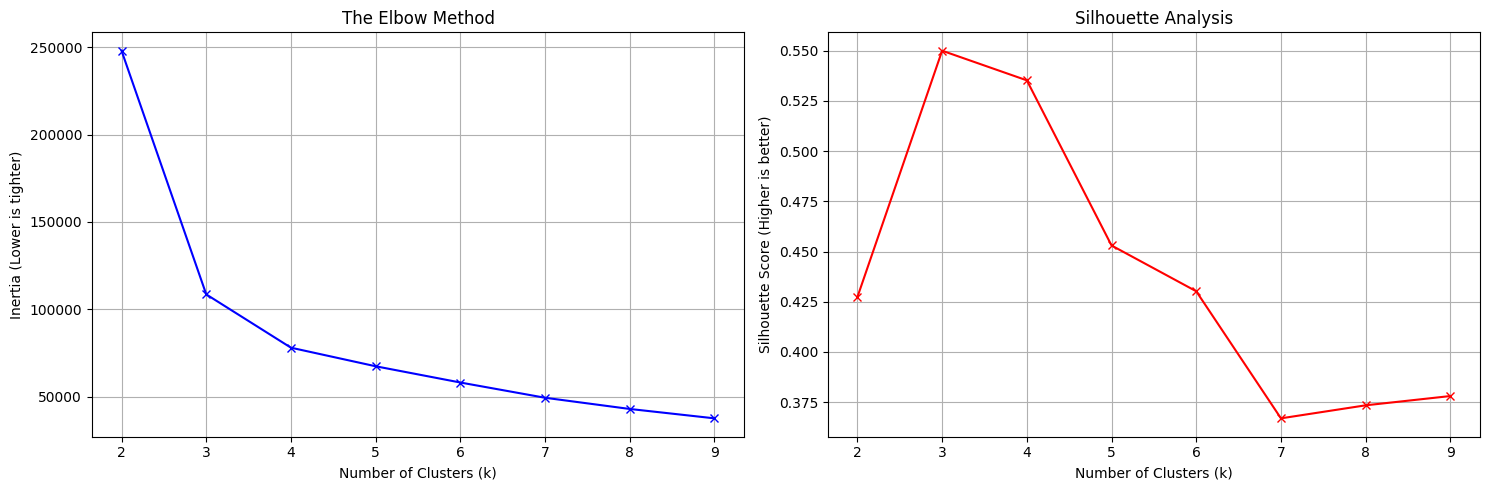

In [26]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_avg = []
K_range = range(2, 10)

for k_val in K_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette_avg.append(silhouette_score(X, labels))

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Plot
ax1.plot(K_range, inertia, 'bx-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Lower is tighter)')
ax1.set_title('The Elbow Method')
ax1.grid(True)

# Silhouette Plot
ax2.plot(K_range, silhouette_avg, 'rx-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score (Higher is better)')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

**How to read these charts:**
*   **Elbow:** Look for the point where the line starts to flatten out. In our messy data, you'll likely see a bend around $k=3$ or $k=4$.
*   **Silhouette:** The peak of this graph represents the point where the clusters are most logically separated.

Compare these results to the scatter plot above! Does the mathematical 'best' match what your eyes see?

### Step 5: Visualizing the 'Mathematical' Winners
To see why the charts peaked or bent where they did, let's look at the data using the $k$ values suggested by those methods.

Usually, **$k=3$** represents the major biological groups we created, while **$k=4$** or higher often starts trying to group the random outliers we added.

In [27]:
import plotly.subplots as sp

# Create a side-by-side comparison of the most likely 'k' values
k_candidates = [3, 4]
fig_comp = sp.make_subplots(rows=1, cols=2, subplot_titles=(f'K=3 (High Silhouette)', f'K=4 (The "Elbow")'))

for i, k_val in enumerate(k_candidates):
    km = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    clusters = km.fit_predict(X)

    # Add data points
    fig_comp.add_trace(
        go.Scatter(x=df['Duration (mins)'], y=df['Heart Rate (BPM)'],
                   mode='markers', marker=dict(color=clusters, colorscale='Viridis'),
                   name=f'k={k_val} clusters'),
        row=1, col=i+1
    )

    # Add centroids
    fig_comp.add_trace(
        go.Scatter(x=km.cluster_centers_[:, 0], y=km.cluster_centers_[:, 1],
                   mode='markers', marker=dict(color='red', symbol='x', size=12),
                   name=f'k={k_val} Centroids'),
        row=1, col=i+1
    )

fig_comp.update_layout(height=500, title_text="Side-by-Side Comparison of Candidate K-Values", showlegend=False)
fig_comp.show()

### Final Conclusion: The Intuition
*   **The Silhouette Peak ($k=3$):** Notice how in the $k=3$ plot, the three main biological groups are cleanly separated. The silhouette score is high because points are very close to their own center and far from others.
*   **The Elbow Point ($k=4$):** By adding a 4th cluster, the 'Inertia' (total spread) drops because the algorithm can finally isolate the random outliers. However, notice how it splits one of the 'natural' groups in half—this is why the silhouette score starts to drop after $k=3$!

### Step 6: Visualizing the Machine Learning 'Loop'
K-Means doesn't find the answer instantly. It follows an iterative process:
1. **Initialization**: Randomly place $k$ centroids.
2. **Assignment**: Assign every data point to its nearest centroid.
3. **Update**: Move centroids to the average location of their assigned points.
4. **Repeat**: Do it again until the centroids stop moving!

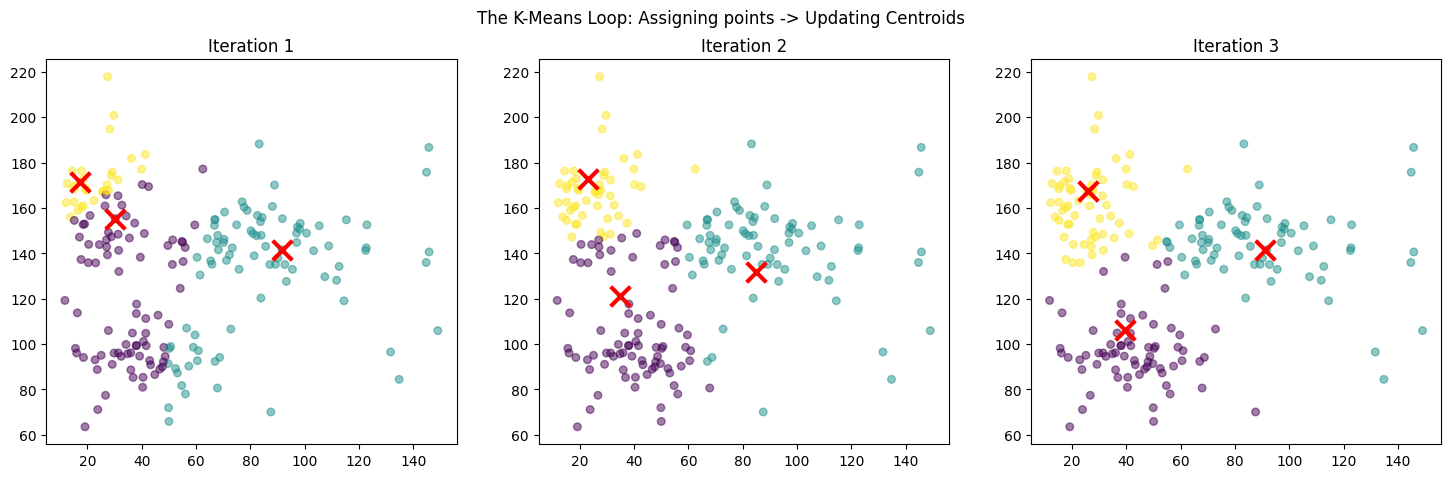

In [28]:
import matplotlib.pyplot as plt

# We will manually run steps of K-Means to show the loop
def plot_kmeans_steps(X, k=3, steps=3):
    # 1. Initialization
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]

    fig, axes = plt.subplots(1, steps, figsize=(18, 5))

    for i in range(steps):
        # 2. Assignment
        distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
        labels = np.argmin(distances, axis=0)

        # Plot current state
        axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.5, s=30)
        axes[i].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3)
        axes[i].set_title(f"Iteration {i+1}")

        # 3. Update (calculate new centroids)
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])
        centroids = new_centroids

    plt.suptitle("The K-Means Loop: Assigning points -> Updating Centroids")
    plt.show()

# Visualize 3 iterations of the 'learning' process
plot_kmeans_steps(X, k=3, steps=3)